In [1]:
import pandas as pd 

In [2]:
DATSET_LOC = "https://raw.githubusercontent.com/GokuMohandas/Made-With-ML/refs/heads/main/datasets/dataset.csv"
df = pd.read_csv(DATSET_LOC)
df.head()

,id,created_on,title,description,tag
0,6,2020-02-20 06:43:18,Comparison between YOLO and RCNN on real world...,Bringing theory to experiment is cool. We can ...,computer-vision
1,7,2020-02-20 06:47:21,"Show, Infer & Tell: Contextual Inference for C...",The beauty of the work lies in the way it arch...,computer-vision
2,9,2020-02-24 16:24:45,Awesome Graph Classification,"A collection of important graph embedding, cla...",other
3,15,2020-02-28 23:55:26,Awesome Monte Carlo Tree Search,A curated list of Monte Carlo tree search pape...,other
4,25,2020-03-07 23:04:31,AttentionWalk,"A PyTorch Implementation of ""Watch Your Step: ...",other


In [3]:
from sklearn.model_selection import train_test_split

In [4]:
df.tag.value_counts()

tag
natural-language-processing    310
computer-vision                285
other                          106
mlops                           63
Name: count, dtype: int64

In [5]:
test_size = 0.2
train_df, val_df = train_test_split(df, stratify=df.tag, test_size=test_size, random_state=100)

In [6]:
train_df.tag.value_counts()

tag
natural-language-processing    248
computer-vision                228
other                           85
mlops                           50
Name: count, dtype: int64

In [7]:
val_df.tag.value_counts() * int((1-test_size) / test_size)

tag
natural-language-processing    248
computer-vision                228
other                           84
mlops                           52
Name: count, dtype: int64

In [8]:
from collections import Counter
import matplotlib.pyplot as plt 
import seaborn as sns; sns.set_theme()
#import warnings; warnings.filterwarnings("ignore")
from wordcloud import WordCloud, STOPWORDS

In [9]:
all_tags = Counter(df.tag)

In [10]:
all_tags.most_common()

[('natural-language-processing', 310),
 ('computer-vision', 285),
 ('other', 106),
 ('mlops', 63)]

/tmp/ipykernel_4115/4213484816.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(tags,rotation = 0, fontsize = 8)


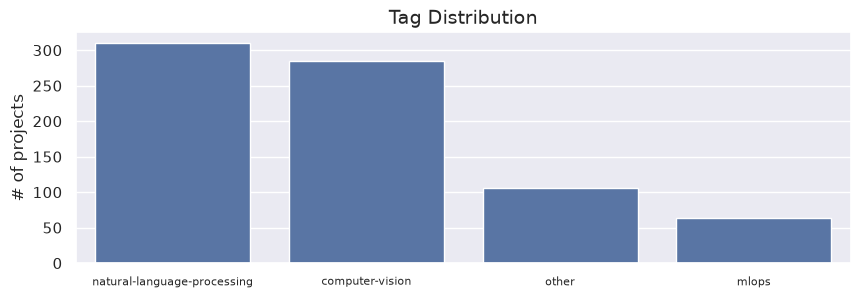

In [11]:
tags, tag_counts = zip(*all_tags.most_common())
plt.figure(figsize=(10,3))
ax = sns.barplot(x=list(tags), y= list(tag_counts))
ax.set_xticklabels(tags,rotation = 0, fontsize = 8)
plt.title("Tag Distribution", fontsize = 14)
plt.ylabel("# of projects", fontsize = 12 )
plt.show()

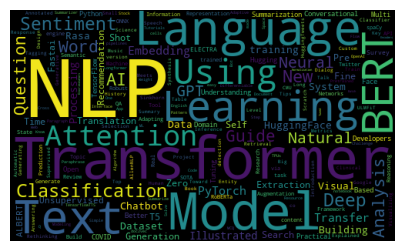

In [12]:
#most frequent tokens for each tag
tag = "natural-language-processing"
plt.figure(figsize=(10,3))
subset = df[df.tag==tag]
text = subset.title.values
cloud = WordCloud(stopwords=STOPWORDS, background_color="black", collocations=False, 
                  width=500, height=300).generate(" ".join(text))
plt.axis("off")
plt.imshow(cloud)

### Preprocessing

In [13]:
import json
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re

In [14]:
# Feature engineering : combining title with description 
#df["text"] = df.title + " " + df.description

In [15]:
nltk.download("stopwords")
STOPWORDS = stopwords.words("english")

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/cherian/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [16]:
#Cleaning 
def clean_text(text, stopwords=STOPWORDS):
    """Clean raw text string."""
    
    # 1. Remove URLs FIRST (before punctuation is destroyed)
    text = re.sub(r"http\S+", "", text)

    # 2. Lowercase
    text = text.lower()

    # 3. Remove stopwords
    # (Doing this before removing punctuation ensures words like "don't" 
    # can be matched correctly if they are in your stopwords list)
    pattern = re.compile(r'\b(' + r"|".join(stopwords) + r")\b\s*")
    text = pattern.sub('', text)

    # 4. Remove all non-alphanumeric characters (The Bulldozer)
    # (We removed the redundant punctuation spacing step entirely)
    text = re.sub("[^A-Za-z0-9]+", " ", text)
    # if punctuations needded
    #text = re.sub(r"([!\"'#$%&()*\+,-./:;<=>?@\\\[\]^_`{|}~])", r" \1 ", text)  # add spacing

    # 5. Spacing and filters
    text = re.sub(" +", " ", text)  # remove multiple spaces
    text = text.strip()             # strip white space at the ends

    return text

In [17]:
# Apply to dataframe
original_df = df.copy()
#df.text = df.text.apply(clean_text)
#print (f"{original_df.text.values[0]}\n{df.text.values[0]}")

In [18]:
# DataFrame cleanup
# df = df.drop(columns=["id", "created_on", "title", "description"], errors="ignore")  # drop unnecessory cols
# df = df.dropna(subset=["tag"])  # drop nulls in target variable 
# df = df[["text", "tag"]]  # rearrange cols
# df.head()

In [19]:
# Label to index
tags = train_df.tag.unique().tolist()
num_classes = len(tags)
class_to_index = {tag: i for i, tag in enumerate(tags)}
class_to_index

{'natural-language-processing': 0,
 'mlops': 1,
 'computer-vision': 2,
 'other': 3}

In [20]:
#df["tag"] = df["tag"].map(class_to_index)
#df.head()

In [21]:
# decode function instead of map so that it can be used in np array or a tensor later
# map() is for pandas df only 
def decode(indices, index_to_class):
    return [index_to_class[index] for index in indices]

In [22]:
index_to_class = {v:k for k, v in class_to_index.items()}


In [23]:
# df.head()["tag"].values extracts a NumPy array, stripping away pandas
#decode(df.head()["tag"].values, index_to_class=index_to_class)

In [24]:
import numpy as np
from transformers import BertTokenizer

In [25]:
# Bert tokenizer
tokenizer = BertTokenizer.from_pretrained("allenai/scibert_scivocab_uncased", return_dict=False)
# moved out of the tokanize funtion so that hugging Face warning and usage of 
# tokens is not repeated each time function is called   

def tokenize(batch):
    # tokenizer = BertTokenizer.from_pretrained("allenai/scibert_scivocab_uncased", return_dict=False)
    encoded_inputs = tokenizer(batch["text"].tolist(), return_tensors="np", padding="longest")
    return dict(ids=encoded_inputs["input_ids"], masks=encoded_inputs["attention_mask"], targets=np.array(batch["tag"]))

In [26]:
# Tokenization
#tokenize(df.head(1))

In [27]:
def preprocess(df, class_to_index):

    df = df.copy() #isolate the original dataframe from changes made in functions
    """Preprocess the data."""
    df["text"] = df.title + " " + df.description  # feature engineering
    df["text"] = df.text.apply(clean_text)  # clean text
    df = df.drop(columns=["id", "created_on", "title", "description"], errors="ignore")  # clean dataframe
    df = df[["text", "tag"]]  # rearrange columns
    df["tag"] = df["tag"].map(class_to_index)  # label encoding
    outputs = tokenize(df)
    return outputs

In [28]:
# Apply
preprocess(df=train_df, class_to_index=class_to_index)

{'ids': array([[  102,   191, 23495, ...,     0,     0,     0],
        [  102,  4417,  2998, ...,     0,     0,     0],
        [  102,  1066,   896, ...,     0,     0,     0],
        ...,
        [  102,  2567,  1995, ...,     0,     0,     0],
        [  102, 28063,   308, ...,     0,     0,     0],
        [  102,  5239,  1572, ...,     0,     0,     0]], shape=(611, 40)),
 'masks': array([[1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        ...,
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0]], shape=(611, 40)),
 'targets': array([0, 0, 0, 1, 0, 0, 2, 3, 2, 0, 2, 0, 0, 3, 0, 2, 2, 2, 2, 3, 0, 2,
        2, 0, 3, 2, 3, 2, 0, 0, 0, 2, 0, 2, 1, 3, 3, 0, 0, 3, 2, 3, 0, 0,
        0, 2, 3, 0, 0, 0, 0, 2, 1, 1, 0, 0, 2, 1, 0, 3, 3, 0, 0, 0, 3, 0,
        3, 0, 0, 2, 2, 1, 0, 2, 2, 2, 1, 3, 0, 2, 0, 2, 0, 2, 2, 1, 3, 1,
        0, 3, 2, 0, 0, 2, 2, 2, 0, 0, 2, 2, 2, 0, 0, 2, 2, 3, 2, 0, 2, 0,

In [29]:
import os 
import random
import torch
#from ray.data.preprocessor import Preprocessor

In [30]:
# Utilities 
def set_seeds(seed=100):
    #set seeds for reproducibility"
    np.random.seed(seed)
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed=seed) # pytorch cpu
    
    # if gpu is available 
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed=seed)
        torch.cuda.manual_seed_all(seed=seed) #if more than 1 gpu

        #cudnn settings 
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    #eval("setattr(torch.backends.cudnn, 'deterministic', True)")
    #eval("setattr(torch.backends.cudnn, 'benchmark', False)")

In [31]:
import json

In [32]:
#class CustomPreprocessor(Preprocessor): - not using ray for now 
# class CustomPreprocessor:
#     def __init__(self):
#         self.class_to_index = {}
#         self.index_to_class = {}

#     def _fit(self, ds):
#         tags = ds["tag"].unique()
#         self.class_to_index = {tag: i for i, tag in enumerate(tags)}
#         self.index_to_class = {v: k for k,v in self.class_to_index.items()}

#     def _transform_pandas(self,batch):
#         return preprocess(batch, class_to_index=self.class_to_index)

#     def save(self,filepath):
#         #Saves the dictionary to a JSON file
#         with open(filepath,"w") as f:
#             json.dump({"class_to_index": self.class_to_index}, f)

#     def load(self,filepath):
#         #loads dic from json file
#         with open(filepath,"r") as f:
#             data = json.load(f)
#             self.class_to_index = data["class_to_index"]
#             self.index_to_class = {v: k for k,v in self.class_to_index.items()}

In [33]:
import torch.nn as nn
from transformers import BertModel

In [34]:
# llm = BertModel.from_pretrained("allenai/scibert_scivocab_uncased", return_dict = False, use_safetensors=True)
# embedding_dim = llm.config.hidden_size

In [35]:
#print(torch.__version__)

In [36]:
# Sample
# text = "Transfer learning with transformers for text classification."
# batch = tokenizer([text], return_tensors="np", padding="longest")
# batch = {k:torch.tensor(v) for k,v in batch.items()}  # convert to torch tensors
# seq, pool = llm(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
# np.shape(seq), np.shape(pool)

In [37]:
import torch.nn.functional as F

In [38]:
class FinetunnedLLM(nn.Module):
    def __init__(self, llm, dropout_p, embedding_dim, num_classes):
        super(FinetunnedLLM,self).__init__()
        self.llm = llm
        self.dropout = nn.Dropout(dropout_p)
        self.fc1 = nn.Linear(embedding_dim,num_classes)

    @property
    def device(self):
        # To dynamically find the device the model weights live on
        return next(self.parameters()).device

    def forward(self,batch_or_ids, masks=None):
        
        # Forward pass for FinetunnedLLM.

        # Accepts either:
        #   1. A dictionary batch from DataLoader: model(batch)
        #   2. Separate positional tensors for MLflow/tracing: model(ids, masks)
        

        if isinstance(batch_or_ids, dict):
            ids = batch_or_ids["ids"]
            masks = batch_or_ids["masks"]
        else:
            ids = batch_or_ids

        #ids, masks = batch["ids"], batch["masks"]

        # Pass tokens through BERT (seq is full sequence, pool is the aggregated [CLS] token)
        seq, pool = self.llm(input_ids = ids, attention_mask=masks)

        # Pass the pooled output through dropout and our final classification layer
        z = self.dropout(pool)
        z = self.fc1(z)
        return z 

    @torch.inference_mode() #stops PyTorch from calculating gradients and saving memory
    def predict(self,batches):

        #turn off dropout 
        self.eval()
        all_y_preds = []

        for batch in batches:
            # 1. Automatically move batch tensors to the model's device
            batch_on_device = {k: v.to(self.device) for k,v in batch.items() if isinstance(v,torch.Tensor)}

            # 2. Run forward pass
            z = self(batch_on_device)

            # 3. Get predicted class indices and move back to CPU as NumPy
            y_pred = torch.argmax(z,dim=1).cpu().numpy()
            all_y_preds.extend(y_pred)

        return np.array(all_y_preds)

    @torch.inference_mode() #stops PyTorch from calculating gradients and saving memory
    def predict_prob(self,batches):

        #turn off dropout 
        self.eval()
        all_y_probs = []

        for batch in batches:
            # 1. Automatically move batch tensors to the model's device
            batch_on_device = {k: v.to(self.device) for k,v in batch.items() if isinstance(v,torch.Tensor)}
            
            # 2. Run forward pass
            z = self(batch_on_device)

            # 3. Calculate probabilities along dim=1 and move back to CPU as NumPy
            y_probs = F.softmax(z, dim=1).cpu().numpy()
            all_y_probs.extend(y_probs)

        return np.array(all_y_probs)


In [39]:
#model = FinetunnedLLM(llm=llm, dropout_p=0.5, embedding_dim=embedding_dim, num_classes=num_classes)

In [40]:
#print (model.named_parameters)

In [41]:
# def pad_array(arr, dtype=np.int32):
#     # Find the maximum length in this specific batch
#     max_len = max(len(row) for row in arr)
    
#     # Create an array of zeros with the max length
#     padded_arr = np.zeros((len(arr), max_len), dtype=dtype)
    
#     # Copy the actual values into the padded array
#     for i, row in enumerate(arr):
#         padded_arr[i, :len(row)] = row
        
#     return padded_arr

In [42]:
# def collate_fn(batch):
#     # batch is a list of dictionaries: [{'ids': [...], 'targets': 1}, {'ids': [...], 'targets': 0}]
    
#     batch["ids"] = pad_array(batch["ids"])
#     batch["masks"] = pad_array(batch["masks"])
    
#     # Pad the sequences
#     padded_ids = pad_array(batch["ids"])
#     padded_masks = pad_array(batch["masks"])
    
#     # Convert to PyTorch tensors
#     return {
#         "ids": torch.tensor(padded_ids, dtype=torch.long),
#         "masks": torch.tensor(padded_masks, dtype=torch.long),
#         "targets": torch.tensor(batch["targets"], dtype=torch.long)
#     }

In [43]:
import torch
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence

In [44]:
class TextDataset(Dataset):
    def __init__(self, tokenized_data):
        # 1. Keep them as raw lists/arrays to allow for variable sequence lengths
        self.ids = tokenized_data["ids"]
        self.masks = tokenized_data["masks"]
        self.targets = tokenized_data["targets"]

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        # 2. Convert the individual sequence to a Tensor here
        return {
            "ids": torch.tensor(self.ids[idx], dtype=torch.long),
            "masks": torch.tensor(self.masks[idx], dtype=torch.long),
            "targets": torch.tensor(self.targets[idx], dtype=torch.long)
        }

In [45]:
def collate_fn(batch):
    # 3. Extract the tensors using the CORRECT keys from __getitem__
    # (Since they are already tensors, we do not call torch.tensor() again)
    ids = [item["ids"] for item in batch]
    masks = [item["masks"] for item in batch]
    
    # 4. For scalar targets, torch.stack is the most efficient way to batch them
    targets = torch.stack([item["targets"] for item in batch])
    
    # 5. Handle dynamic padding and stacking
    padded_ids = pad_sequence(ids, batch_first=True, padding_value=0)
    padded_masks = pad_sequence(masks, batch_first=True, padding_value=0)
    
    # 6. Return the final dictionary of perfectly shaped Tensors
    return {
        "ids": padded_ids,
        "masks": padded_masks,
        "targets": targets
    }



In [46]:
# sample_batch = preprocess(train_df.head(5), class_to_index=class_to_index)
# sample_batch_tensor = TextDataset(sample_batch)
# sample_list = [sample_batch_tensor[i] for i in range(5)]
# collate_fn(sample_list)

In [47]:
# DataLoader initialization
train_outputs = preprocess(train_df, class_to_index=class_to_index)
train_dataset = TextDataset(train_outputs)

val_outputs = preprocess(val_df, class_to_index=class_to_index)
val_dataset = TextDataset(val_outputs)

In [48]:
def train_step(ds, model, num_classes, loss_fn, optimizer):
    # Set model to training mode
    model.train()

    loss = 0.0
  
    for i, batch in enumerate(ds):

        # Move batch to the exact device the model lives on
        batch = {k: v.to(model.device) for k, v in batch.items()}

        # reset the gradients
        optimizer.zero_grad()
        
        # Forward pass
        z = model(batch)

        #one hot for loss calculation
        targets = F.one_hot(batch["targets"], num_classes=num_classes).float()
        
        # Compute loss
        J = loss_fn(z, targets)
        
        # Backward pass and optimization step
        J.backward()
        optimizer.step()
        
        loss += (J.detach().item() - loss) / (i + 1)  # running average of loss
    
    return loss

In [49]:
def eval_step(ds, model, num_classes, loss_fn):
    # Set model to evaluation mode
    model.eval()

    loss = 0.0
    y_trues = []
    y_preds = []
   
    with torch.inference_mode():  # Disable gradient calculation for evaluation
        for i, batch in enumerate(ds):

            # Move batch to the exact device the model lives on
            batch = {k: v.to(model.device) for k, v in batch.items()}

            # Forward pass
            z = model(batch)

            # One-hot encode targets for loss calculation
            targets = F.one_hot(batch["targets"], num_classes=num_classes).float()
            
            # Compute loss
            J = loss_fn(z, targets).item()
            loss += (J - loss) / (i + 1)  # running average of loss

            # Store predictions and targets for metrics calculation
            preds = torch.argmax(z, dim=1).cpu().numpy()
            y_preds.extend(preds)
            y_trues.extend(batch["targets"].cpu().numpy())
    
    return loss, np.vstack(y_preds), np.vstack(y_trues)

In [50]:
import mlflow
from pathlib import Path
import time
from mlflow.models.signature import ModelSignature
from mlflow.types.schema import Schema, TensorSpec
#from mlflow.models import infer_signature

In [51]:
#config mlflow
MODEL_REGISTRY = Path("../mlruns").resolve()
Path(MODEL_REGISTRY).mkdir(parents=True, exist_ok=True)
#print(f"Model registry initialized at: {MODEL_REGISTRY.resolve()}")

db_path = MODEL_REGISTRY / "mlflow.db"

#setup local tracking uri
MLFLOW_TRACKING_URI = f"sqlite:///{db_path}"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

#verify mlflow tracking uri
#print(f"MLflow Tracking URI set to:{mlflow.get_tracking_uri()}")

In [52]:
# Create dynamic experiment name
experiment_name = f"llm-{int(time.time())}"

#set artifact location for mlflow experiment
artifact_location = MODEL_REGISTRY.as_uri()

try:
    mlflow.create_experiment(
        name=experiment_name, 
        artifact_location=artifact_location
    )
except mlflow.exceptions.MlflowException:
    # If the experiment already exists, we can ignore the exception
    pass

# Tell MLflow to use this experiment (If it doesn't exist, MLflow creates it automatically)
mlflow.set_experiment(experiment_name)

<Experiment: artifact_location='file:///home/cherian/mlops/mlops-production-pipeline/mlruns', creation_time=1786351724939, effective_trace_archival_retention=None, experiment_id='2', last_update_time=1786351724939, lifecycle_stage='active', name='llm-1786351723', tags={}, trace_location=None, workspace='default'>

In [53]:
# train_loader = DataLoader(
#         dataset=train_dataset,
#         batch_size=64,
#         shuffle=True,
#         collate_fn=collate_fn,
#         num_workers=4, 
#         pin_memory=True,
#     )
# batch = next(iter(train_loader))
# print(type(batch))

# if isinstance(batch, dict):
#     print("Keys in batch:", batch.keys())
# else:
#     print("Number of items in batch tuple:", len(batch))

In [54]:
# #config mlflow
# MODEL_REGISTRY = Path("../mlruns").resolve()
# Path(MODEL_REGISTRY).mkdir(parents=True, exist_ok=True)
# #print(f"Model registry initialized at: {MODEL_REGISTRY.resolve()}")

# db_path = MODEL_REGISTRY / "mlflow.db"

# #setup local tracking uri
# MLFLOW_TRACKING_URI = f"sqlite:///{db_path}"
# mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

# #verify mlflow tracking uri
# #print(f"MLflow Tracking URI set to:{mlflow.get_tracking_uri()}")

# # Create dynamic experiment name
# experiment_name = f"llm-{int(time.time())}"

# #set artifact location for mlflow experiment
# artifact_location = MODEL_REGISTRY.as_uri()

# try:
#     mlflow.create_experiment(
#         name=experiment_name, 
#         artifact_location=artifact_location
#     )
# except mlflow.exceptions.MlflowException:
#     # If the experiment already exists, we can ignore the exception
#     pass

# # Tell MLflow to use this experiment (If it doesn't exist, MLflow creates it automatically)
# mlflow.set_experiment(experiment_name)

# def training_loop(train_ds, val_ds, llm, device, config):
#     # Set seeds for reproducibility
#     set_seeds()

#     #hyperparameters
#     dropout_p = config["dropout_p"]
#     lr = config["lr"]
#     lr_factor = config["lr_factor"]
#     lr_patience = config["lr_patience"]
#     num_epochs = config["num_epochs"]
#     batch_size = config["batch_size"]
#     num_classes = config["num_classes"]

#     # Create DataLoaders for training and validation datasets
#     train_loader = DataLoader(
#         dataset=train_ds,
#         batch_size=batch_size,
#         shuffle=True,
#         collate_fn=collate_fn,
#         num_workers=4, 
#         pin_memory=True,
#     )
#     val_loader = DataLoader(
#         dataset=val_ds,
#         batch_size=batch_size,
#         shuffle=False,
#         collate_fn=collate_fn,
#         num_workers=4,
#         pin_memory=True,
#     )

#     # Initialize model, loss function, optimizer and scheduler
#     model = FinetunnedLLM(llm=llm, dropout_p=dropout_p, embedding_dim=llm.config.hidden_size, num_classes=num_classes)
#     model = model.to(device)  # Move model to device BEFORE initializing the optimizer

#     loss_fn = nn.BCEWithLogitsLoss()
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min', factor=lr_factor, patience=lr_patience)

#     # Tracker for saving the best model
#     best_val_loss = float('inf')

#     # Grab the dictionary batch for input example
#     batch = next(iter(train_loader))
#     
#     #  Build a clean tuple for MLflow (excluding 'targets')
#     # We use [:1] to give MLflow exactly one example sequence
#     input_example = (
#         batch["ids"][:1].to(device),
#         batch["masks"][:1].to(device)
#     )

#     # Move to CPU and Numpy just to read the dtypes easily
#     ids_sample = batch["ids"][:1].cpu().numpy()
#     masks_sample = batch["masks"][:1].cpu().numpy()

#     # Option1. Statically define the TensorSpec Schema! - bulletproof
#     input_schema = Schema([
#         TensorSpec(ids_sample.dtype, (-1,-1), name="ids"), # wilc card shape for dynamic sequence length
#         TensorSpec(masks_sample.dtype, (-1,-1), name="masks")
#     ])

#     # Package it into an MLflow ModelSignature - may cause issues
#     signature = ModelSignature(inputs=input_schema)

#     # Option2. Dynamically infer the signature from the input example 
#     #signature = infer_signature(model_input =input_example)

#     #integrate mlflow for logging metrics and model artifacts
#     with mlflow.start_run() as run:
#         mlflow.log_params(config)  # Log hyperparameters

#         for epoch in range(num_epochs):
#             train_loss = train_step(ds = train_loader, model= model,num_classes=num_classes,
#                                     loss_fn=loss_fn, optimizer=optimizer)
#             val_loss, _, _ = eval_step(ds = val_loader, model= model, num_classes=num_classes,
#                                            loss_fn=loss_fn)
#             scheduler.step(val_loss)

#             curent_lr = optimizer.param_groups[0]["lr"]

#             mlflow.log_metrics({
#                 "training_loss": train_loss,
#                 "validation_loss": val_loss,
#                 "lr": curent_lr
#             },step = epoch)

#             #checkpoint
#             # metrics = dict(epoch=epoch, lr=optimizer.param_groups[0]["lr"],
#             #                train_loss=train_loss, val_loss=val_loss)
#             print(f"Epoch {epoch + 1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

#             # Save model if validation loss improves
#             if val_loss < best_val_loss:
#                 best_val_loss = val_loss

#                 # option A for light weight - Save local state_dict file
#                 #torch.save(model.state_dict(), "best_model.pt")
#                 #mlflow.log_artifact("best_model.pt", artifact_path="checkpoints")

#                 #option B - Log model to MLflow registry format (Recommended for inference later)
#                 mlflow.pytorch.log_model(model, name="best_model",
#                                          input_example=input_example,signature=signature,
#                                            serialization_format= "pickle")


#                 print("Saved new best model!")

In [55]:
def training_loop(train_ds, val_ds, llm, device, config):
    # Set seeds for reproducibility
    set_seeds()

    #hyperparameters
    dropout_p = config["dropout_p"]
    lr = config["lr"]
    lr_factor = config["lr_factor"]
    lr_patience = config["lr_patience"]
    num_epochs = config["num_epochs"]
    batch_size = config["batch_size"]
    num_classes = config["num_classes"]

    # Create DataLoaders for training and validation datasets
    train_loader = DataLoader(
        dataset=train_ds,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn,
        num_workers=4, 
        pin_memory=True,
    )
    val_loader = DataLoader(
        dataset=val_ds,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=4,
        pin_memory=True,
    )

    # Initialize model, loss function, optimizer and scheduler
    model = FinetunnedLLM(llm=llm, dropout_p=dropout_p, embedding_dim=llm.config.hidden_size, num_classes=num_classes)
    model = model.to(device)  # Move model to device BEFORE initializing the optimizer

    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min', factor=lr_factor, patience=lr_patience)

    # Tracker for saving the best model
    best_val_loss = float('inf')

    # Grab the dictionary batch for input example
    batch = next(iter(train_loader))
    
    #  Build a clean tuple for MLflow (excluding 'targets')
    # We use [:1] to give MLflow exactly one example sequence
    input_example = (
        batch["ids"][:1].to(device),
        batch["masks"][:1].to(device)
    )

    # Move to CPU and Numpy just to read the dtypes easily
    ids_sample = batch["ids"][:1].cpu().numpy()
    masks_sample = batch["masks"][:1].cpu().numpy()

    # Option1. Statically define the TensorSpec Schema! - bulletproof
    input_schema = Schema([
        TensorSpec(ids_sample.dtype, (-1,-1), name="ids"), # wilc card shape for dynamic sequence length
        TensorSpec(masks_sample.dtype, (-1,-1), name="masks")
    ])

    # Package it into an MLflow ModelSignature - may cause issues
    signature = ModelSignature(inputs=input_schema)

    # Option2. Dynamically infer the signature from the input example 
    #signature = infer_signature(model_input =input_example)

    #integrate mlflow for logging metrics and model artifacts
    with mlflow.start_run() as run:
        mlflow.log_params(config)  # Log hyperparameters

        for epoch in range(num_epochs):
            train_loss = train_step(ds = train_loader, model= model,num_classes=num_classes,
                                    loss_fn=loss_fn, optimizer=optimizer)
            val_loss, _, _ = eval_step(ds = val_loader, model= model, num_classes=num_classes,
                                           loss_fn=loss_fn)
            scheduler.step(val_loss)

            curent_lr = optimizer.param_groups[0]["lr"]

            mlflow.log_metrics({
                "training_loss": train_loss,
                "validation_loss": val_loss,
                "lr": curent_lr
            },step = epoch)

            #checkpoint
            # metrics = dict(epoch=epoch, lr=optimizer.param_groups[0]["lr"],
            #                train_loss=train_loss, val_loss=val_loss)
            print(f"Epoch {epoch + 1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

            # Save model if validation loss improves
            if val_loss < best_val_loss:
                best_val_loss = val_loss

                # Save local state_dict file
                torch.save(model.state_dict(), "tmp_best_model.pt")
                #mlflow.log_artifact("best_model.pt", artifact_path="checkpoints")


                print("Saved new best model!")
        # After ALL epochs finish, load best weights and log to MLflow ONCE
        model.load_state_dict(torch.load("tmp_best_model.pt"))
        
        mlflow.pytorch.log_model(
            model, 
            name ="best_model",
            input_example=input_example,
            signature=signature,
            serialization_format="pickle"
        )
        print("Logged single best model artifact to MLflow!")

In [56]:
# Train loop config
train_loop_config = {
    "dropout_p": 0.5,
    "lr": 1e-4,
    "lr_factor": 0.5,
    "lr_patience": 3,
    "num_epochs": 15,
    "batch_size": 32,
    "num_classes": num_classes,
}

In [57]:
import gc

In [58]:
# Clear GPU Memory Safely
# Delete unused variables that reference GPU memory
if 'llm' in locals():
    del llm
    print("Deleted llm from locals()")
if 'best_model' in locals():
    del best_model
    print("Deleted best_model from locals()")

In [59]:
gc.collect() # Invoke Python's garbage collector to reclaim unreachable memory

1136

In [60]:
# Release unused cached memory from the allocator
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [61]:
print("Initializing a fresh BERT model...")
llm = BertModel.from_pretrained("allenai/scibert_scivocab_uncased", return_dict=False, use_safetensors=True)

Initializing a fresh BERT model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [62]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}\n" + "-"*30)

Training on: cuda
------------------------------


In [63]:
# Execute the Training Loop
training_loop(
    train_ds=train_dataset, 
    val_ds=val_dataset, 
    llm=llm, 
    device=device, 
    config=train_loop_config
)
print("-" * 30 + "\nTraining Complete!")

Epoch 1/15, Train Loss: 0.4505, Val Loss: 0.2770
Saved new best model!
Epoch 2/15, Train Loss: 0.2017, Val Loss: 0.1994
Saved new best model!
Epoch 3/15, Train Loss: 0.1048, Val Loss: 0.1961
Saved new best model!
Epoch 4/15, Train Loss: 0.0500, Val Loss: 0.2429
Epoch 5/15, Train Loss: 0.0442, Val Loss: 0.1917
Saved new best model!
Epoch 6/15, Train Loss: 0.0293, Val Loss: 0.2058
Epoch 7/15, Train Loss: 0.0266, Val Loss: 0.1921
Epoch 8/15, Train Loss: 0.0254, Val Loss: 0.2603
Epoch 9/15, Train Loss: 0.0733, Val Loss: 0.2345
Epoch 10/15, Train Loss: 0.0281, Val Loss: 0.2533
Epoch 11/15, Train Loss: 0.0079, Val Loss: 0.2728
Epoch 12/15, Train Loss: 0.0065, Val Loss: 0.2775
Epoch 13/15, Train Loss: 0.0060, Val Loss: 0.2793
Epoch 14/15, Train Loss: 0.0062, Val Loss: 0.2924
Epoch 15/15, Train Loss: 0.0072, Val Loss: 0.2436


/tmp/ipykernel_4115/3208830381.py:104: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("tmp_best_model.pt"))
2026/08/10 08:51:10 WARNING mlflo

Logged single best model artifact to MLflow!
------------------------------
Training Complete!


In [64]:
# print("-" * 30 + "Initializing best model...")
# # Initialize a fresh model using the exact same config parameters
# best_model = FinetunnedLLM(
#     llm=llm, 
#     dropout_p=train_loop_config["dropout_p"], 
#     embedding_dim=llm.config.hidden_size, 
#     num_classes=train_loop_config["num_classes"]
# )
# print("-" * 30 + "Loading best model...")
# # Load the peak-performance weights from disk
# best_model.load_state_dict(torch.load("best_model.pt", weights_only=True))
# best_model = best_model.to(device)

# print("Best model successfully loaded into memory and ready for evaluation!")

In [65]:
print("-" * 30 + "Loading best model...")
def load_model_from_run(run_id: str, device: torch.device = torch.device("cpu")):
        
    # Format the MLflow URI pointing to your artifact folder
    model_uri = f"runs:/{run_id}/best_model"
    
    # Reconstruct the full nn.Module with optimal weights loaded
    model = mlflow.pytorch.load_model(model_uri)
    
    # Move model to the desired device (CPU/CUDA) and set to eval mode
    model = model.to(device)
    model.eval()
    print("Best model successfully loaded into memory and ready for prediction!")
    return model

------------------------------Loading best model...


In [66]:
# Sorted runs
sorted_runs = mlflow.search_runs(experiment_names=[experiment_name], order_by=["metrics.val_loss ASC"])
# sorted_runs = mlflow.search_runs(
#     search_all_experiments=True, 
#     order_by=["metrics.val_loss ASC"]
# )
sorted_runs

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.training_loss,metrics.validation_loss,metrics.lr,params.num_classes,params.lr_patience,params.lr,params.lr_factor,params.dropout_p,params.batch_size,params.num_epochs,tags.mlflow.source.name,tags.mlflow.runName,tags.mlflow.source.type,tags.mlflow.user
0,2c8247a87a3c4115bde428c04db500c3,2,FINISHED,file:///home/cherian/mlops/mlops-production-pi...,2026-08-10 08:48:51.607000+00:00,2026-08-10 08:51:39.994000+00:00,0.007217,0.243628,0.000025,4,3,0.0001,0.5,0.5,32,15,train_with_mlflow.ipynb,clumsy-koi-465,NOTEBOOK,cherian


In [67]:
best_run_id = sorted_runs.iloc[0]["run_id"]

# Load the PyTorch model
device = "cuda" if torch.cuda.is_available() else "cpu"
predictor = load_model_from_run(run_id=best_run_id, device=device)

Best model successfully loaded into memory and ready for prediction!


In [68]:
HOLDOUT_LOC = "https://raw.githubusercontent.com/GokuMohandas/Made-With-ML/refs/heads/main/datasets/holdout.csv"
test_df = pd.read_csv(HOLDOUT_LOC)
test_outputs = preprocess(test_df, class_to_index=class_to_index)
test_dataset = TextDataset(test_outputs)

In [69]:
# test_loader = DataLoader(
#     dataset=test_dataset,
#     batch_size=test_dataset.__len__(),  
#     # Load the entire test dataset in one batch but may encounter 
#     # memory issues if the dataset is too large. Adjust batch_size as needed.
#     shuffle=False,
#     collate_fn=collate_fn,
#     num_workers=4,
#     pin_memory=True,
# )
#z = predictor.predict(batches=test_loader)

In [70]:
# y_pred = np.stack(z)
# print (y_pred)

In [71]:
from sklearn.metrics import precision_recall_fscore_support

In [72]:
# metrics = precision_recall_fscore_support(y_true, y_pred, average="weighted")
# {"precision": metrics[0], "recall": metrics[1], "f1": metrics[2]}

In [73]:
#print(metrics)

In [74]:
def evaluate(ds, predictor):
    # Evaluate the model on a given dataset.
    
    # Create DataLoader for the dataset
    loader = DataLoader(
        dataset=ds,
        #batch_size=ds.__len__(),  # Load the entire dataset in one batch
        batch_size=ds.__len__() // 4,  # Load the entire dataset in 4 batch depending on memory constraints
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=4,
        pin_memory=True,
    )

    # Get true labels
    y_true = ds.targets

    # Get predictions from the predictor
    z = predictor.predict(batches=loader)
    y_pred = np.stack(z)

    # Calculate metrics
    metrics = precision_recall_fscore_support(y_true, y_pred, average="weighted")
    
    return {"precision": metrics[0], "recall": metrics[1], "f1": metrics[2]}

In [75]:
def format_prob(prob, index_to_class):
    #Format the probability output into a dictionary with class labels
    d= {}
    for i,item in enumerate(prob):
        d[index_to_class[i]] = float(item)
    return d

In [76]:
def predict_with_prob(ds, predictor):
    # Predict with probabilities and format the output."""
    
    # Create DataLoader for the dataset
    loader = DataLoader(
        dataset=ds,
        batch_size=ds.__len__(),  # Load the entire dataset in one batch
        #batch_size=ds.__len__() // 4,  
        # # Load the entire dataset in 4 batch depending on memory constraints
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=4,
        pin_memory=True,
    )

    # Get predictions with probabilities from the predictor
    prob = predictor.predict_prob(batches=loader)

    results = []

    for i, p in enumerate(prob):
        tag = decode([int(np.argmax(p))], index_to_class=index_to_class)[0]
        results.append({"prediction": tag, "probabilities": format_prob(p, index_to_class)})
    
    return results

In [77]:
performance = evaluate(ds=test_dataset, predictor=predictor)
print (json.dumps(performance, indent=2))

{
  "precision": 0.9433444391559573,
  "recall": 0.9424083769633508,
  "f1": 0.941894792751642
}


In [78]:
# Predict on sample
title = "Transfer learning with transformers"
description = "Using transformers for transfer learning on text classification tasks."
sample_df = pd.DataFrame([{"title": title, "description": description, "tag": "other"}])
sample_outputs = preprocess(sample_df, class_to_index=class_to_index)
sample_dataset = TextDataset(sample_outputs)
predict_with_prob(ds=sample_dataset, predictor=predictor)

[{'prediction': 'natural-language-processing',
  'probabilities': {'natural-language-processing': 0.999739944934845,
   'mlops': 8.757763862377033e-05,
   'computer-vision': 5.9011828852817416e-05,
   'other': 0.0001134748017648235}}]